In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [3]:
slc = pd.read_csv("D:\Projects\GitRepositories\TheAWOLthing\AWOL_Research\data\soldat_info.csv")
slin = pd.read_csv('D:\Projects\GitRepositories\TheAWOLthing\AWOL_Research\scripts\soldiers_1.csv')

In [4]:
slc.sample(500)

,detail_url,name,birth_date,death_date,burial_date,birth_settlement,birth_community,birth_district,birth_oblast,death_settlement,death_community,death_district,death_oblast,rank,military_unit,sources,is_missing
120196,https://ualosses.org/en/soldier/lukach-oleksan...,Lukach Oleksandr Ivanovych,"July 23, 1987",NaN,NaN,Kharkiv,Kharkivska urban community,Kharkiv District,Kharkiv Oblast,Torets'k,Toretska urban community,Bakhmut District,Donetsk Oblast,Unknown,Unknown,https://wanted.mvs.gov.ua/searchbezvesti?PRUFM...,True
41200,https://ualosses.org/en/soldier/stanishevskyj-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106452,https://ualosses.org/en/soldier/fomych-illja-m...,Fomych Illja Mykolajovych,"Sept. 3, 1970",NaN,NaN,Krasnjanka,Tyvrivska settlement community,Vinnytsia District,Vinnytsia Oblast,Andriyivka,Velykonovosilkivska settlement community,Volnovakha District,Donetsk Oblast,Unknown,Unknown,https://wanted.mvs.gov.ua/searchbezvesti?PRUFM...,True
139648,https://ualosses.org/en/soldier/buchynskyj-ole...,Buchyns'kyj Oleksij Ihorovych,"Feb. 9, 1984",NaN,NaN,Nemija,Mohyliv-Podilska urban community,Mohyliv-Podilskyi District,Vinnytsia Oblast,Pervomajs'ke,Ocheretynska settlement community,Pokrovsk District,Donetsk Oblast,Unknown,Unknown,https://wanted.mvs.gov.ua/searchbezvesti?PRUFM...,True
61286,https://ualosses.org/en/soldier/lomydze-beso-g...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106981,https://ualosses.org/en/soldier/bublyk-ihor-an...,Bublyk Ihor Anatolijovych,?,?,?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Soldier,Unknown,https://www.president.gov.ua/documents/7432024...,False
52052,https://ualosses.org/en/soldier/hut-ruslan-jur...,Hut Ruslan Jurijovych,"Feb. 25, 1994",NaN,NaN,Dnipro,Dniprovska urban community,Dnipro District,Dnipropetrovsk Oblast,Petrivka,Selydivska urban community,Pokrovsk District,Donetsk Oblast,Unknown,Unknown,https://wanted.mvs.gov.ua/searchbezvesti?PRUFM...,True
72606,https://ualosses.org/en/soldier/horbunov-oleks...,Horbunov Oleksandr Mykolajovych,"March 12, 1983",NaN,NaN,Movnyky,Lytovezka rural community,Volodymyr-Volynskyi District,Volyn Oblast,Pershotravneve,Dvorichanska settlement community,Kupiansk District,Kharkiv Oblast,Unknown,Unknown,https://wanted.mvs.gov.ua/searchbezvesti?PRUFM...,True
109121,https://ualosses.org/en/soldier/kinash-ruslan-...,Kinash Ruslan Mykhajlovych,"Jan. 24, 1979",NaN,NaN,Shchyrets',Shchyretska settlement community,Lviv District,Lviv Oblast,Chasiv Jar,Chasovoiarska urban community,Bakhmut District,Donetsk Oblast,Unknown,Unknown,https://wanted.mvs.gov.ua/searchbezvesti?PRUFM...,True


In [5]:
slc['detail_url'].value_counts()

detail_url
https://ualosses.org/en/soldier/semenenko-danylo-artemovych-2002-08-05-19-kharkiv-3rd-brigade-of-operational-assignment-soldier/             7
https://ualosses.org/en/soldier/podzizej-ruslan-tarasovych-1973-08-24-51-drevyni-33rd-separate-mechanized-brigade-senior-soldier/            7
https://ualosses.org/en/soldier/babenko-andrij-ihorovych-1989-01-02-34-melnyky-soldier/                                                      7
https://ualosses.org/en/soldier/marton-oleksandr-mykhajlovych-1999-04-14-25-dorobratovo-453rd-separate-infantry-battalion-senior-soldier/    7
https://ualosses.org/en/soldier/kurjata-mykhajlo-heorhijovych-1989-06-22-34-berezne-72nd-separate-mechanized-brigade-senior-soldier/         7
                                                                                                                                            ..
https://ualosses.org/en/soldier/markov-rostyslav-svjatoslavovych-1986-03-02-lviv/                                                  

In [6]:
missing_df = slin[~slin['detail_url'].isin(slc['detail_url'])]
missing_df2 = slc[~slc['detail_url'].isin(slin['detail_url'])]
nodp = slc['detail_url'].drop_duplicates()
nodpslc = slc.drop_duplicates()

In [7]:
slin['age'] = pd.to_datetime(slin['birth_date'], errors='coerce').apply(lambda x: pd.Timestamp.now() - x).dt.days // 365
nd = slin.drop_duplicates(['detail_url'])

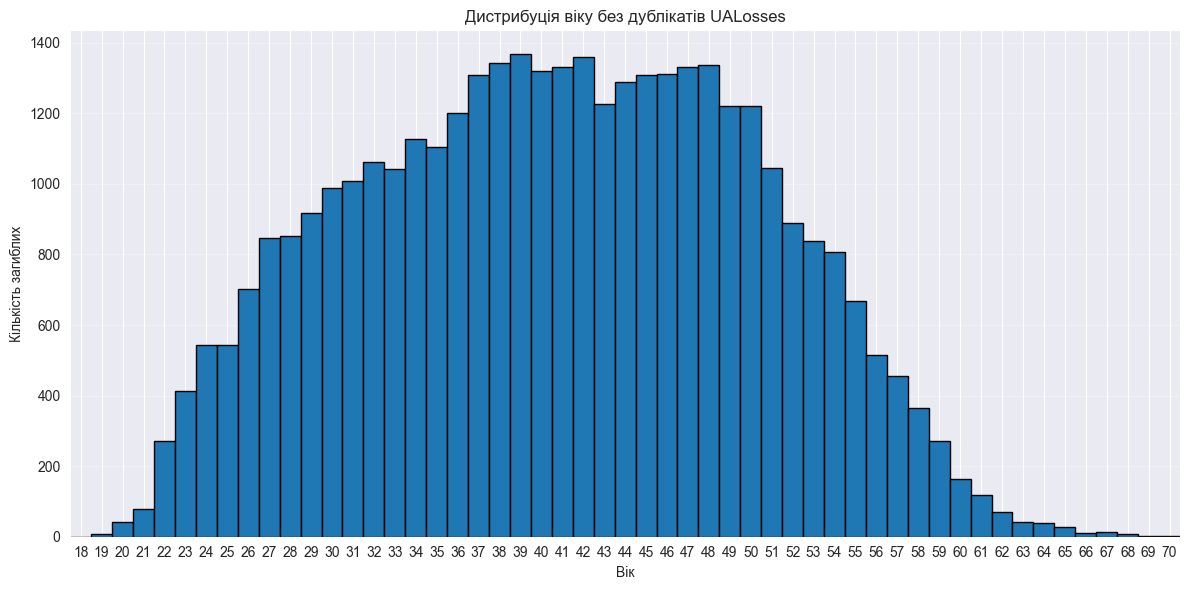

In [18]:
# Filter ages between 18 and 70 (and clean)
ages = pd.to_numeric(nd['age'], errors='coerce').dropna()
ages = ages[(ages >= 18) & (ages <= 70)]

# Bin edges at half-integers so each whole age is centered in a 1-year bin
bin_edges = np.arange(17.5, 70.5 + 1e-9, 1)

plt.figure(figsize=(12, 6))
plt.hist(ages, bins=bin_edges, edgecolor='black')

plt.title('Дистрибуція віку без дублікатів UALosses')
plt.xlabel('Вік')
plt.ylabel('Кількість загиблих')
plt.xticks(np.arange(18, 71, 1))
plt.xlim(17.5, 70.5)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Робота над експертизою дублікатів



In [10]:

DATA_PATH = Path("soldiers.csv")

df = pd.read_csv(
    DATA_PATH,
    na_values=["NaN", "Unknown", "?", ""],   # treat these strings as missing
    keep_default_na=True
)

# Rename the first, unnamed column to 'id'
first_col = df.columns[0]
df.rename(columns={first_col: "id"}, inplace=True)

# Parse the three date columns.  They come in various textual formats
# so we let pandas coerce bad parses to NaT.
date_cols = ["birth_date", "death_date"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=False)

print(df.shape)
df.head()


(142540, 6)


,id,detail_url,birth_date,death_date,location,image_url
0,Koljadych Mykola Mykolajovych,https://ualosses.org/en/soldier/koljadych-myko...,NaT,NaT,"May 21, 2001 - (March 6, 2024)",https://ualosses.org/static/img/photos/3077072...
1,Hlushko Ruslan Ivanovych,https://ualosses.org/en/soldier/hlushko-ruslan...,NaT,NaT,"Aug. 13, 1979 - (March 20, 2024)",https://ualosses.org/static/img/photos/3080419...
2,Chopyk Stepan Vasyl'ovych,https://ualosses.org/en/soldier/chopyk-stepan-...,NaT,NaT,"July 25, 1987 - (Feb. 22, 2024)",https://ualosses.org/static/img/photos/3076799...
3,Nikitin Vitalij Viktorovych,https://ualosses.org/en/soldier/nikitin-vitali...,NaT,NaT,"Aug. 8, 1976 - (Feb. 25, 2024)",https://ualosses.org/static/img/photos/3076934...
4,Leshko Ruslan Ivanovych,https://ualosses.org/en/soldier/leshko-ruslan-...,NaT,NaT,"Aug. 13, 1979 - (March 20, 2024)",https://ualosses.org/static/img/photos/%D0%9B%...


In [12]:
vc = df.value_counts(dropna=False)
dupe_groups = vc[vc > 1]

total_dupe_rows = int(dupe_groups.sum())
share = total_dupe_rows / len(df)
print(f"{total_dupe_rows:,} exact-duplicate rows ({share:.1%} of the file)")

hist = dupe_groups.value_counts().sort_index()
print("Histogram of repetition counts:")
print(hist)

# Sanity check
from_hist = int(np.dot(hist.index.to_numpy(), hist.values))
assert from_hist == total_dupe_rows, (from_hist, total_dupe_rows)


71,730 exact-duplicate rows (50.3% of the file)
Histogram of repetition counts:
count
2    22891
3     6198
4     1394
5      256
6       83
Name: count, dtype: int64


In [14]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np


# =========================# LOAD # =========================#

slc = pd.read_csv(r"D:\Projects\GitRepositories\TheAWOLthing\AWOL_Research\data\soldat_info.csv")
slin = pd.read_csv(r"D:\Projects\GitRepositories\TheAWOLthing\AWOL_Research\scripts\soldiers_1.csv")

# =========================# LIGHT CLEANUP / NORMALIZATION # =========================#

colmap = {}
cols_lower = {c.lower(): c for c in slc.columns}

# map common names to a canonical set
if 'detail_url' in cols_lower:
    colmap[cols_lower['detail_url']] = 'detail_url'
elif 'url' in cols_lower:
    colmap[cols_lower['url']] = 'detail_url'

# name column
for k in ['name','full_name','soldier_name']:
    if k in cols_lower:
        colmap[cols_lower[k]] = 'name'; break

# birth date
for k in ['birth_date','dob','date_of_birth']:
    if k in cols_lower:
        colmap[cols_lower[k]] = 'birth_date'; break

# death date (optional)
for k in ['death_date','dod','date_of_death']:
    if k in cols_lower:
        colmap[cols_lower[k]] = 'death_date'; break

# id column (optional)
for k in ['id','idx','index','_id','soldier_id']:
    if k in cols_lower:
        colmap[cols_lower[k]] = 'id'; break

slc = slc.rename(columns=colmap)

# Normalize URL (strip spaces, keep trailing slash consistent)
if 'detail_url' in slc.columns:
    slc['detail_url'] = (
        slc['detail_url']
        .astype(str)
        .str.strip()
        .str.replace(r'\s+', '', regex=True)
    )
    # standardize trailing slash
    slc['detail_url'] = np.where(
        slc['detail_url'].str.endswith('/'),
        slc['detail_url'],
        slc['detail_url'] + '/'
    )

# Parse dates if present (coerce errors; treat '?', 'NaN', empty as NA)
for c in ['birth_date', 'death_date']:
    if c in slc.columns:
        slc[c] = pd.to_datetime(slc[c], errors='coerce')

# Also coerce typical missing tokens in string columns
slc = slc.replace({"?": pd.NA, "NaN": pd.NA, "Unknown": pd.NA, "": pd.NA})

# For soldiers_1.csv we assume it has at least: detail_url and page (or something like that).
# We'll try to normalize similarly.
slin_cols_lower = {c.lower(): c for c in slin.columns}
if 'detail_url' not in slin.columns:
    # try to rename candidate URL column
    for k in ['detail_url','url','href','link']:
        if k in slin_cols_lower:
            slin = slin.rename(columns={slin_cols_lower[k]: 'detail_url'})
            break
# standardize slin URLs the same way
if 'detail_url' in slin.columns:
    slin['detail_url'] = (
        slin['detail_url']
        .astype(str)
        .str.strip()
        .str.replace(r'\s+', '', regex=True)
    )
    slin['detail_url'] = np.where(
        slin['detail_url'].str.endswith('/'),
        slin['detail_url'],
        slin['detail_url'] + '/'
    )

# Try to find a "page" column in soldiers_1 (used for cross-check)
page_col = None
for k in ['page','pages','source_page','list_page']:
    if k in slin_cols_lower:
        page_col = slin_cols_lower[k]
        break


# =========================# EXACT DUPLICATES # =========================#

# Count distinct rows and duplicates across ALL columns (treat NaNs as equal)
vc_all = slc.value_counts(dropna=False)
dupe_groups_all = vc_all[vc_all > 1]
total_dupe_rows_all = int(dupe_groups_all.sum())
share_all = total_dupe_rows_all / len(slc)
n_unique_rows_all = int((vc_all == 1).sum())
print(f"[ALL-COLUMN] rows: {len(slc):,}")
print(f"[ALL-COLUMN] exact-duplicate rows (including originals): {total_dupe_rows_all:,} ({share_all:.1%})")
print(f"[ALL-COLUMN] unique rows (appear exactly once): {n_unique_rows_all:,}")

# Histogram: how many groups have frequency 2,3,4,...
hist_all = dupe_groups_all.value_counts().sort_index()
print("\n[ALL-COLUMN] Histogram of repetition counts (group frequency -> #groups):")
print(hist_all)

# Sanity check
from_hist_all = int(np.dot(hist_all.index.to_numpy(), hist_all.values))
assert from_hist_all == total_dupe_rows_all, (from_hist_all, total_dupe_rows_all)

# Save a browsable CSV of duplicated groups (all columns)
dupe_table_all = (dupe_groups_all
                  .rename('freq')
                  .reset_index()
                  .sort_values('freq', ascending=False))
dupe_table_all.to_csv("dupe_groups_all_columns.csv", index=False)


# =========================# DUPLICATES BY DETAIL_URL # =========================#

if 'detail_url' in slc.columns:
    url_counts = slc['detail_url'].value_counts(dropna=False)
    url_dupe_groups = url_counts[url_counts > 1]

    total_rows_in_dupe_urls = int(url_dupe_groups.sum())         # includes originals
    n_unique_urls = int((url_counts == 1).sum())
    n_total_urls = int(url_counts.shape[0])

    print(f"\n[BY URL] total rows: {len(slc):,}")
    print(f"[BY URL] total distinct URLs: {n_total_urls:,}")
    print(f"[BY URL] URLs appearing exactly once: {n_unique_urls:,}")
    print(f"[BY URL] rows that belong to duplicated URLs: {total_rows_in_dupe_urls:,} "
          f"({total_rows_in_dupe_urls/len(slc):.1%} of all rows)")

    # Histogram of URL repetition counts
    hist_url = url_dupe_groups.value_counts().sort_index()
    print("\n[BY URL] Histogram of repetition counts (URL frequency -> #URLs):")
    print(hist_url)

    # Sanity check
    from_hist_url = int(np.dot(hist_url.index.to_numpy(), hist_url.values))
    assert from_hist_url == total_rows_in_dupe_urls, (from_hist_url, total_rows_in_dupe_urls)

    # Save suspicious URLs
    # Save suspicious URLs
    url_dupe_table = (
        url_dupe_groups
        .rename_axis('detail_url')   # set index name for the URL column
        .reset_index(name='freq')    # turn index into a column named 'detail_url'; counts -> 'freq'
        .sort_values('freq', ascending=False)
    )
    url_dupe_table.to_csv("dupe_groups_by_url.csv", index=False)

else:
    print("\n[BY URL] 'detail_url' column not found; skipping URL-based duplicate analysis.")
    url_dupe_table = pd.DataFrame(columns=['detail_url','freq'])

# =========================
# 4) CROSS-CHECK WITH soldiers_1 (pages per URL)
# =========================
if 'detail_url' in slc.columns and 'detail_url' in slin.columns and page_col is not None:
    # Only keep URLs we actually saw in the main file
    slin_sub = slin[['detail_url', page_col]].dropna(subset=['detail_url']).copy()

    # Pages per URL (distinct)
    pages_per_url = (slin_sub
                     .drop_duplicates(['detail_url', page_col])
                     .groupby('detail_url', dropna=False)[page_col]
                     .agg(lambda s: sorted(set(s)))
                     .reset_index()
                     .rename(columns={page_col: 'pages_found'}))

    # How many distinct pages list this URL?
    pages_per_url['n_pages'] = pages_per_url['pages_found'].apply(len)

    # If we have the URL-dupe table, join it to see which duplicated URLs are spread across pages
    if not url_dupe_table.empty:
        url_dupe_with_pages = url_dupe_table.merge(pages_per_url, on='detail_url', how='left')
        # Fill those without page info
        url_dupe_with_pages['n_pages'] = url_dupe_with_pages['n_pages'].fillna(0).astype(int)
        url_dupe_with_pages.to_csv("dupe_urls_with_pages.csv", index=False)

        # Quick view: how many duplicated URLs appear across >1 page?
        multi_page = (url_dupe_with_pages['n_pages'] > 1).sum()
        print(f"\n[CROSS-CHECK] duplicated URLs that appear on >1 page: {multi_page:,} "
              f"out of {len(url_dupe_with_pages):,} duplicated URLs")
    else:
        # Even if no duplicates by URL, we can still save pages per URL
        pages_per_url.to_csv("pages_per_url.csv", index=False)
        print("\n[CROSS-CHECK] Wrote pages_per_url.csv (no duplicated URLs detected).")
else:
    print("\n[CROSS-CHECK] Could not run page cross-check (missing 'detail_url' or page column).")


# =========================# FINAL COUNTS # =========================#

# Unique rows (all columns) = groups with freq==1
n_unique_rows_all = int((vc_all == 1).sum())           # already computed above
n_total_rows = len(slc)
n_dup_rows_all = total_dupe_rows_all                   # includes originals in duplicate groups

print("\n================ SUMMARY ================")
print(f"Total rows: {n_total_rows:,}")
print(f"Unique rows (all columns): {n_unique_rows_all:,} "
      f"({n_unique_rows_all/n_total_rows:.1%})")
print(f"Rows belonging to duplicate groups (all columns): {n_dup_rows_all:,} "
      f"({n_dup_rows_all/n_total_rows:.1%})")

if 'detail_url' in slc.columns:
    print(f"Distinct detail_url values: {int(url_counts.shape[0]):,}")
    print(f"detail_url values appearing once: {int((url_counts == 1).sum()):,}")
    print(f"Rows in duplicated detail_url groups: {total_rows_in_dupe_urls:,} "
          f"({total_rows_in_dupe_urls/n_total_rows:.1%})")

print("\nWrote:")
print("  - dupe_groups_all_columns.csv      (each distinct duplicated row with its frequency)")
print("  - dupe_groups_by_url.csv           (each duplicated URL with its frequency)")
print("  - dupe_urls_with_pages.csv         (duplicated URLs + which pages list them) [if page info found]")



[ALL-COLUMN] rows: 142,644
[ALL-COLUMN] exact-duplicate rows (including originals): 89,957 (63.1%)
[ALL-COLUMN] unique rows (appear exactly once): 52,687

[ALL-COLUMN] Histogram of repetition counts (group frequency -> #groups):
count
2    26907
3     8194
4     2155
5      454
6       85
7       23
Name: count, dtype: int64

[BY URL] total rows: 142,644
[BY URL] total distinct URLs: 90,505
[BY URL] URLs appearing exactly once: 52,687
[BY URL] rows that belong to duplicated URLs: 89,957 (63.1% of all rows)

[BY URL] Histogram of repetition counts (URL frequency -> #URLs):
count
2    26907
3     8194
4     2155
5      454
6       85
7       23
Name: count, dtype: int64

[CROSS-CHECK] duplicated URLs that appear on >1 page: 8,620 out of 37,818 duplicated URLs

================ SUMMARY ================
Total rows: 142,644
Unique rows (all columns): 52,687 (36.9%)
Rows belonging to duplicate groups (all columns): 89,957 (63.1%)
Distinct detail_url values: 90,505
detail_url values appearing